In [1]:

import sys
original_sys_path = sys.path.copy()
sys.path.append('../')
from utils import *


/home/kai/miniconda3/envs/tensorflow/lib/python3.10/site-packages/qiskit_dynamics/dispatch/backends/jax.py:34: UserWarning: The functionality in the perturbation module of Qiskit Dynamics requires a JAX version <= 0.4.6, due to a bug in JAX versions > 0.4.6. For versions 0.4.4, 0.4.5, and 0.4.6, using the perturbation module functionality requires setting os.environ['JAX_JIT_PJIT_API_MERGE'] = '0' before importing JAX or Dynamics.
  warnings.warn(


In [2]:
ql = 25
ol = 50
system = fluxonium_oscillator_system(
    EJ = 2.5,
    EC = 0.65,
    EL = 0.12,
    Er = 7.05877808,
    g_strength = 0.2,
    qubit_level = ql,
    osc_level = ol,
    kappa = 1e-3
,
    products_to_keep=[[ql, ol] for ql in [1,2] for ol in range(25) ],
    computaional_states = '1,2',
    w_d = 7.0585
    )

tot_time =int(594.3 + 30)
tlist = np.linspace(0, tot_time, tot_time)


# 1 load result, truncate to 2-level

In [3]:
with open('../pickles/mesolve_temp_2.5_kappa1em3.pkl', 'rb') as file:
    results1 = pickle.load(file)


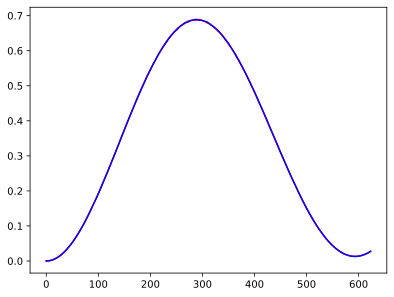

In [5]:
plt.plot(results1[0].expect[1],color = 'red')
plt.plot(results1[1].expect[1],color = 'blue')

# plt.ylim(0,0.1)

In [6]:
from tqdm.notebook import tqdm
for result in [results1[0],results1[1]]:
    result.twolevel_states = [dressed_to_2_level_dm(state, 
                                                    system.product_to_dressed, 
                                                    system.qbt.truncated_dim,
                                                    system.osc.truncated_dim,
                                                    system.computaional_states[0],
                                                    system.computaional_states[1],
                                                    products_to_keep=None)
                               for state in tqdm(result.states, desc=f"Processing states with {dressed_to_2_level_dm.__name__}")]
    

Processing states with dressed_to_2_level_dm:   0%|          | 0/624 [00:00<?, ?it/s]

Processing states with dressed_to_2_level_dm:   0%|          | 0/624 [00:00<?, ?it/s]

In [7]:
with open('../pickles/mesolve_temp_2.5_kappa1em3_2_level.pkl', 'wb') as file:
    pickle.dump(results1, file)


In [8]:
with open('../pickles/mesolve_temp_2.5_kappa1em3_2_level.pkl', 'rb') as file:
    results1 = pickle.load(file) 

Text(0.5, 0, 'ns')

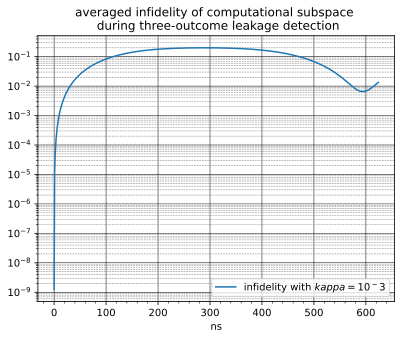

In [10]:

zero = qutip.basis(2, 0)
one = qutip.basis(2, 1)


states_ideal  = [(zero +  one).unit(),
                (zero - one).unit(), ]


def calc_average_fidelity_with_phase(phase,dms,states_ideal):
    gate = qutip.qip.operations.phasegate(phase)
    fid=[]
    for dm,dm_ideal in zip(dms,states_ideal):
        # new_dm = gate*dm*gate.dag()
        # fid.append(qutip.fidelity(new_dm, dm_ideal))
        fid.append(qutip.fidelity(dm, gate*dm_ideal))
    return 1-sum(fid)/len(fid)


from scipy.optimize import minimize
results = results1

infidelity = []
phase = []
for idx in range(tot_time):
    dms = [result.twolevel_states[idx] for result in results]
    def objective_function(phase):
        return calc_average_fidelity_with_phase(phase[0], dms, states_ideal)
    initial_phase = [0.0]
    bounds = [(0, 2 * 3.141592653589793)]
    opt_result = minimize(objective_function, initial_phase,method="COBYLA")
    infidelity.append(opt_result.fun)
    phase.append(opt_result.x[0])

plt.plot(results[0].times,infidelity,label = rf"infidelity with $kappa=10^{-3}$")


plt.grid(which='major', linestyle='-', linewidth='0.5', color='black')
plt.minorticks_on()
plt.gca().xaxis.grid(False, which='minor')
plt.grid(which='minor', linestyle='--', linewidth='0.5', color='gray', axis='y') # Specify axis='y' for y-axis minor grid

plt.legend()
plt.yscale('log')
plt.title("averaged infidelity of computational subspace \n during three-outcome leakage detection")
plt.xlabel("ns")

Text(0.5, 0, 'ns')

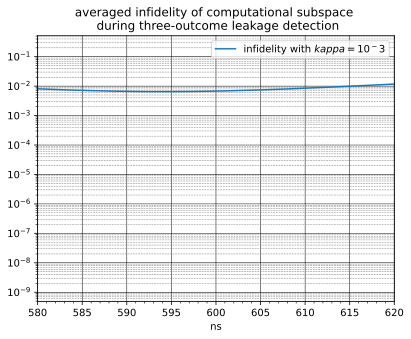

In [12]:

plt.plot(results[0].times,infidelity,label = rf"infidelity with $kappa=10^{-3}$")

plt.xlim(580,620)
plt.grid(which='major', linestyle='-', linewidth='0.5', color='black')
plt.minorticks_on()
plt.gca().xaxis.grid(False, which='minor')
plt.grid(which='minor', linestyle='--', linewidth='0.5', color='gray', axis='y') # Specify axis='y' for y-axis minor grid

plt.legend()
plt.yscale('log')
plt.title("averaged infidelity of computational subspace \n during three-outcome leakage detection")
plt.xlabel("ns")